# PreProcessing: Deteksi Outlier & Imputasi Missing Value serta Ekstraksi Fitur Pada NO2

### 1. Deteksi Outliers pada Data Kualitas Udara di Kecamatan Kerek

In [5]:
import pandas as pd

# Membaca data gabungan kualitas udara Tuban
df = pd.read_csv("KualitasUdaraKerek.csv")

# Daftar kolom fitur polutan yang akan dicek outlier-nya
# (Sesuaikan dengan nama kolom polutan yang ada di DataFrame Anda)
fitur_polutan = ['CO', 'NO2', 'SO2', 'O3']

for kolom in fitur_polutan:
    if kolom in df.columns:
        Q1 = df[kolom].quantile(0.25)
        Q3 = df[kolom].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)

        
        outliers_iqr = df[
            (df[kolom] < lower_bound) | 
            (df[kolom] > upper_bound)
        ]

        print(f"=== Parameter: {kolom} ===")
        print(f"Jumlah Outlier : {len(outliers_iqr)}")
        if len(outliers_iqr) > 0:
            print(outliers_iqr[['date', kolom]].head())
        print("-" * 35 + "\n")

=== Parameter: CO ===
Jumlah Outlier : 4
                         date        CO
38   2025-10-07T00:00:00.000Z  0.042697
40   2025-10-09T00:00:00.000Z  0.041038
335  2026-07-31T00:00:00.000Z  0.039562
349  2026-08-14T00:00:00.000Z  0.039993
-----------------------------------

=== Parameter: NO2 ===
Jumlah Outlier : 3
                         date      NO2
24   2025-09-23T00:00:00.000Z  0.00010
270  2026-05-27T00:00:00.000Z  0.00011
345  2026-08-10T00:00:00.000Z  0.00011
-----------------------------------

=== Parameter: SO2 ===
Jumlah Outlier : 10
                         date     SO2
9    2025-09-08T00:00:00.000Z -0.0004
12   2025-09-11T00:00:00.000Z -0.0004
23   2025-09-22T00:00:00.000Z  0.0006
120  2025-12-28T00:00:00.000Z  0.0004
268  2026-05-25T00:00:00.000Z  0.0005
-----------------------------------

=== Parameter: O3 ===
Jumlah Outlier : 5
                        date        O3
1   2025-08-31T00:00:00.000Z  0.122804
56  2025-10-25T00:00:00.000Z  0.123395
57  2025-10-26T00:00:

### 2. Merubah Outliers Menjadi NaN serta Imputasi Missing Values dan Outliers (NaN)

In [6]:
import pandas as pd
import numpy as np

# 1. Load data
df = pd.read_csv("NO2 Kerek.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')

cols = ['NO2']

# 2. Ubah outliers pada data asli menjadi NaN terlebih dahulu
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Ganti nilai di luar batas IQR menjadi NaN
    df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col] = np.nan

# 3. Sekarang lakukan imputasi (missing value asli + outliers yang jadi NaN) sekaligus
df_clean = df.interpolate(method='time').ffill().bfill()

# 4. Cek hasil akhir
print("Sisa Missing Value:", df_clean.isnull().sum().sum())
df_clean.to_csv('NO2-Kerek-Clean.csv')

Sisa Missing Value: 0


In [7]:
#CO
import pandas as pd
import numpy as np

# 1. Load data
df = pd.read_csv("CO Kerek.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')

cols = ['CO']

# 2. Ubah outliers pada data asli menjadi NaN terlebih dahulu
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Ganti nilai di luar batas IQR menjadi NaN
    df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col] = np.nan

# 3. Sekarang lakukan imputasi (missing value asli + outliers yang jadi NaN) sekaligus
df_clean = df.interpolate(method='time').ffill().bfill()

# 4. Cek hasil akhir
print("Sisa Missing Value:", df_clean.isnull().sum().sum())
df_clean.to_csv('CO-Kerek-Clean.csv')

Sisa Missing Value: 0


In [8]:
#SO2
import pandas as pd
import numpy as np

# 1. Load data
df = pd.read_csv("SO2 Kerek.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')

cols = ['SO2']

# 2. Ubah outliers pada data asli menjadi NaN terlebih dahulu
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Ganti nilai di luar batas IQR menjadi NaN
    df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col] = np.nan

# 3. Sekarang lakukan imputasi (missing value asli + outliers yang jadi NaN) sekaligus
df_clean = df.interpolate(method='time').ffill().bfill()

# 4. Cek hasil akhir
print("Sisa Missing Value:", df_clean.isnull().sum().sum())
df_clean.to_csv('SO2-Kerek-Clean.csv')

Sisa Missing Value: 0


### 3 Visualisasi Data Sebelum dan Sesudah Imputasi
Visualisasi membandingkan data yang masih memiliki outlier dengan data yang sudah di-interpolasi.

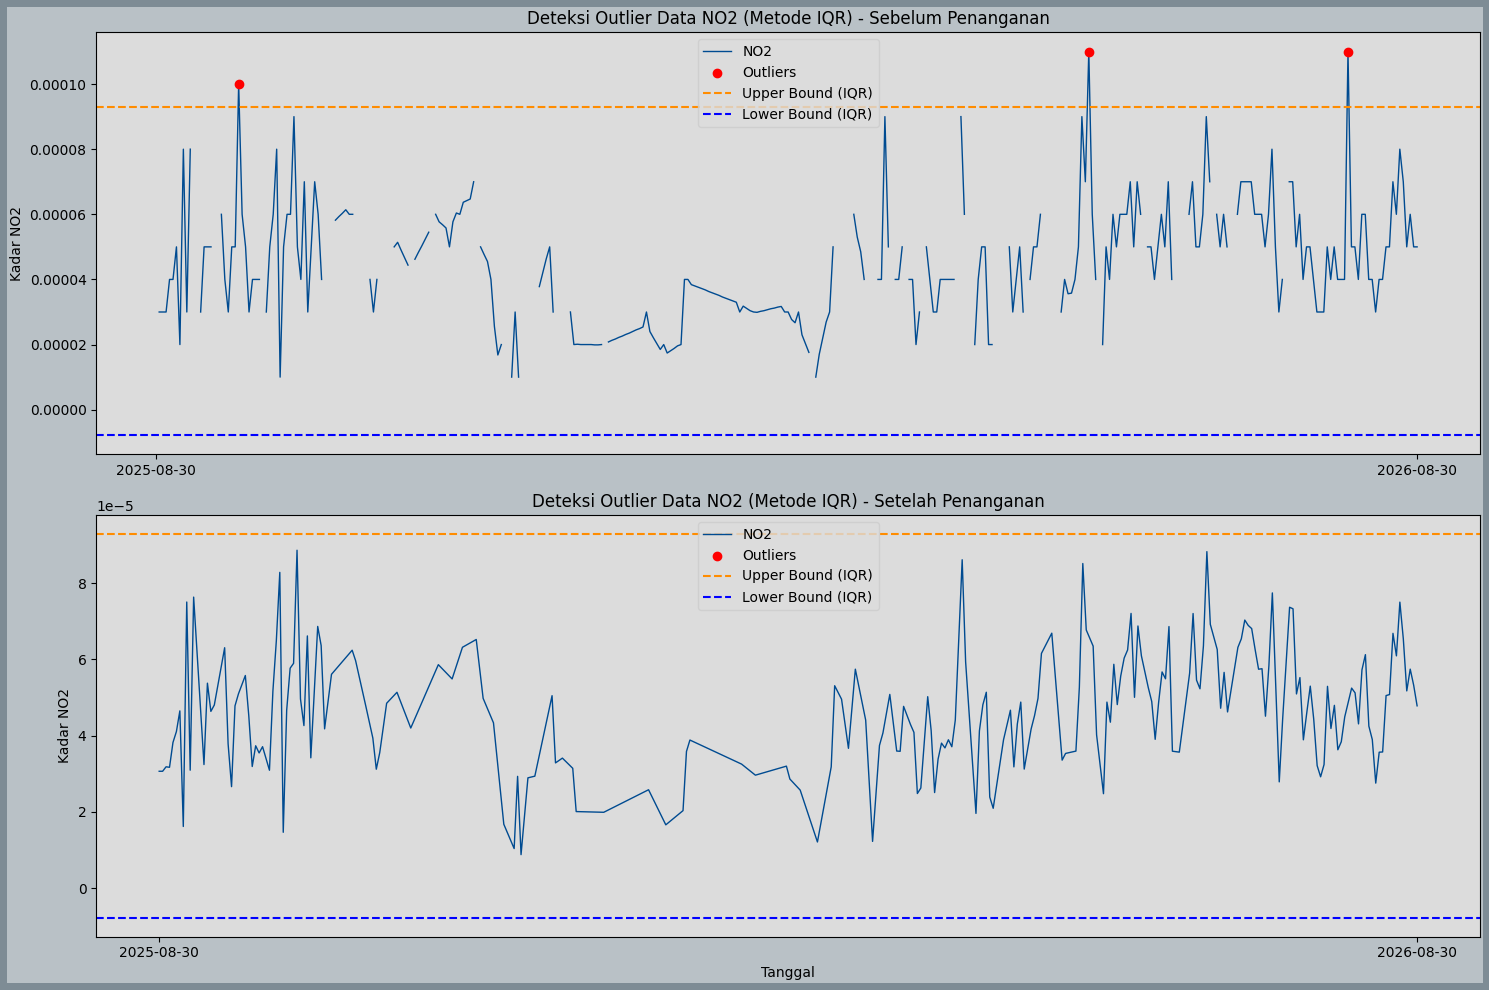

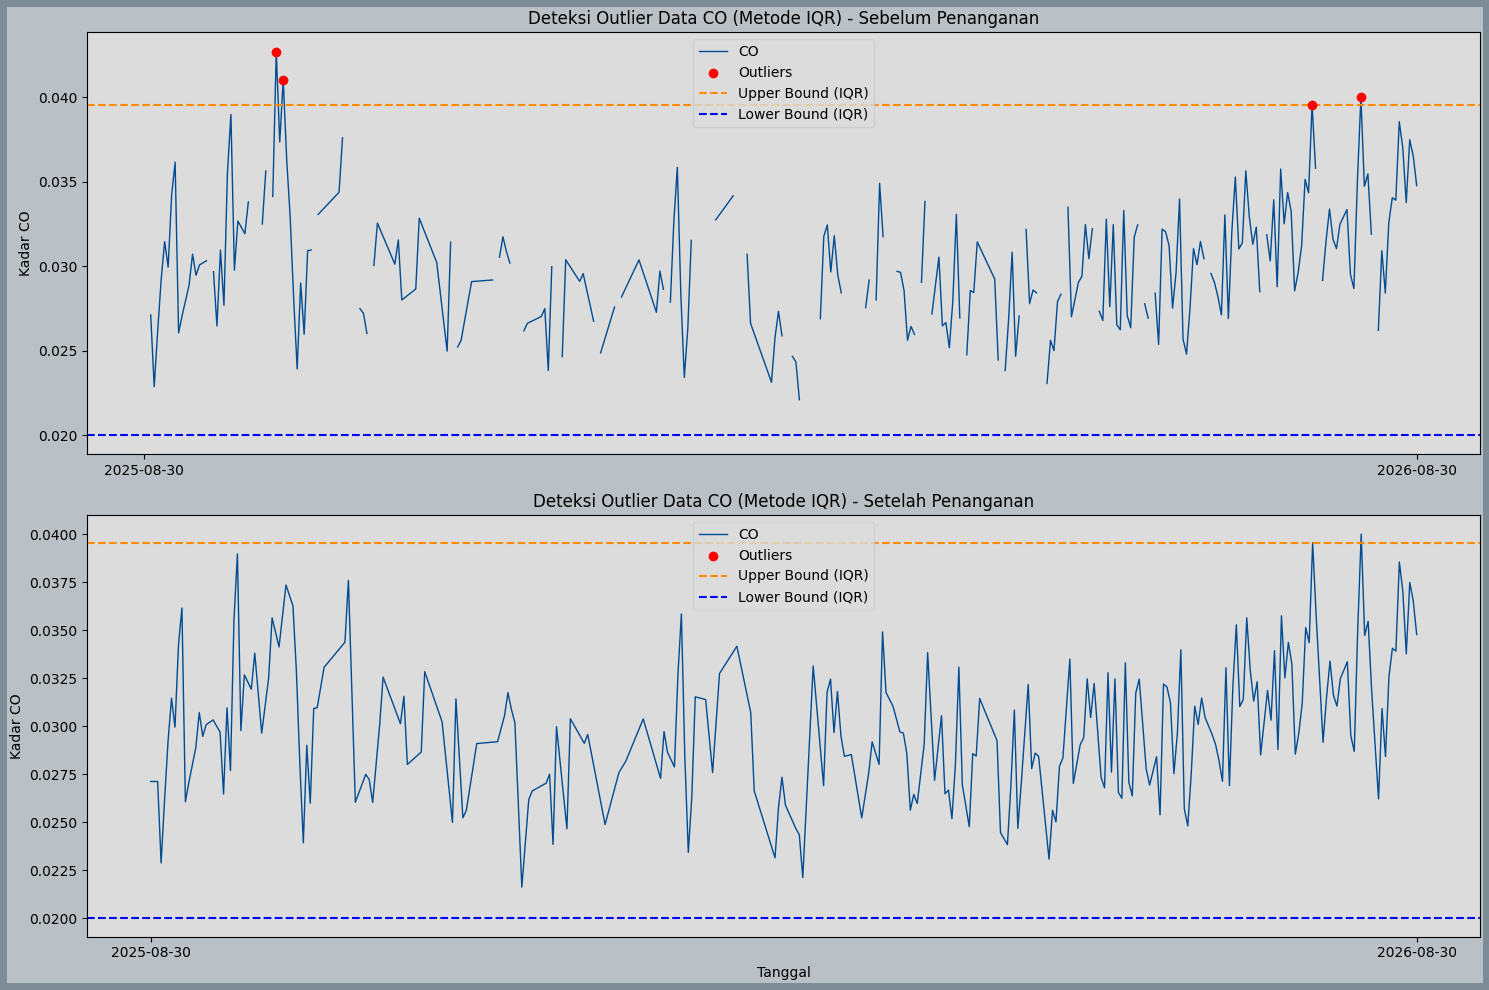

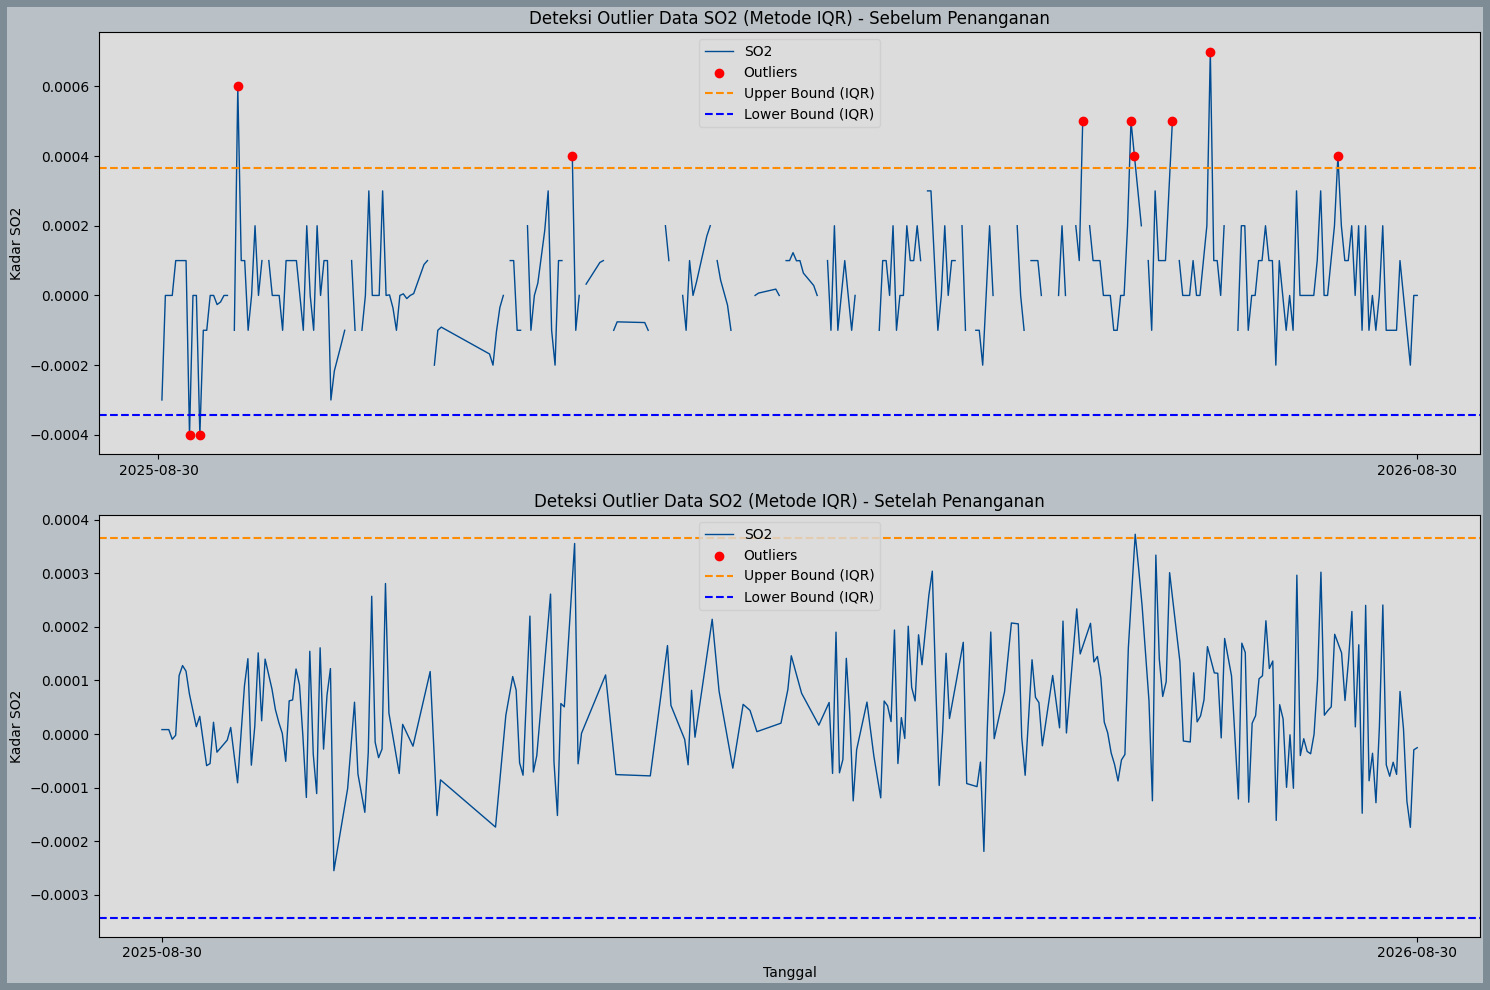

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load original data with outliers
df_raw = pd.read_csv('KualitasUdaraKerek.csv')
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw.set_index('date', inplace=True)

pollutants = ['NO2', 'CO', 'SO2']

for pol in pollutants:
    try:
        # Load cleaned data
        df_clean = pd.read_csv(f'{pol}-Kerek-Clean.csv')
        df_clean['date'] = pd.to_datetime(df_clean['date'])
        df_clean.set_index('date', inplace=True)
        
        # Hitung IQR untuk batas atas dan bawah
        Q1 = df_raw[pol].quantile(0.25)
        Q3 = df_raw[pol].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Cari titik outlier di data asli
        outliers = df_raw[(df_raw[pol] < lower_bound) | (df_raw[pol] > upper_bound)]
        
        # Styling
        plt.rcParams['axes.facecolor'] = '#dcdcdc'
        plt.rcParams['figure.facecolor'] = '#b9c1c6'
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
        
        # --- Plot 1: Data Asli (Sebelum Penanganan) ---
        ax1.plot(df_raw.index, df_raw[pol], color='#004b91', linewidth=1, label=pol)
        ax1.scatter(outliers.index, outliers[pol], color='red', zorder=5, label='Outliers', marker='o')
        ax1.axhline(y=upper_bound, color='darkorange', linestyle='--', label='Upper Bound (IQR)')
        ax1.axhline(y=lower_bound, color='blue', linestyle='--', label='Lower Bound (IQR)')
        
        ax1.set_title(f'Deteksi Outlier Data {pol} (Metode IQR) - Sebelum Penanganan')
        ax1.set_ylabel(f'Kadar {pol}')
        ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.0), fancybox=True, facecolor='#dcdcdc')
        
        # Set x-ticks hanya awal dan akhir tanggal
        first_date = df_raw.index.min()
        last_date = df_raw.index.max()
        ax1.set_xticks([first_date, last_date])
        ax1.set_xticklabels([first_date.strftime('%Y-%m-%d'), last_date.strftime('%Y-%m-%d')])
        
        # --- Plot 2: Data Bersih (Setelah Penanganan) ---
        ax2.plot(df_clean.index, df_clean[pol], color='#004b91', linewidth=1, label=pol)
        # Biarkan legend ada meskipun tidak ada outlier lagi, sesuai gaya
        ax2.scatter([], [], color='red', label='Outliers', marker='o')
        ax2.axhline(y=upper_bound, color='darkorange', linestyle='--', label='Upper Bound (IQR)')
        ax2.axhline(y=lower_bound, color='blue', linestyle='--', label='Lower Bound (IQR)')
        
        ax2.set_title(f'Deteksi Outlier Data {pol} (Metode IQR) - Setelah Penanganan')
        ax2.set_xlabel('Tanggal')
        ax2.set_ylabel(f'Kadar {pol}')
        ax2.legend(loc='upper center', bbox_to_anchor=(0.5, 1.0), fancybox=True, facecolor='#dcdcdc')
        
        ax2.set_xticks([first_date, last_date])
        ax2.set_xticklabels([first_date.strftime('%Y-%m-%d'), last_date.strftime('%Y-%m-%d')])
        
        # Tambahkan border pada figure mirip seperti di gambar
        fig.patch.set_edgecolor('#7e8c95')
        fig.patch.set_linewidth(10)
        
        plt.tight_layout()
        plt.show()
    except FileNotFoundError:
        print(f'File {pol}-Kerek-Clean.csv tidak ditemukan.')


### 4 Visualisasi Timeseries Gabungan Tiga Polutan
Visualisasi ini menampilkan data ketiga polutan (NO2, CO, SO2) dalam satu grafik setelah dilakukan interpolasi.

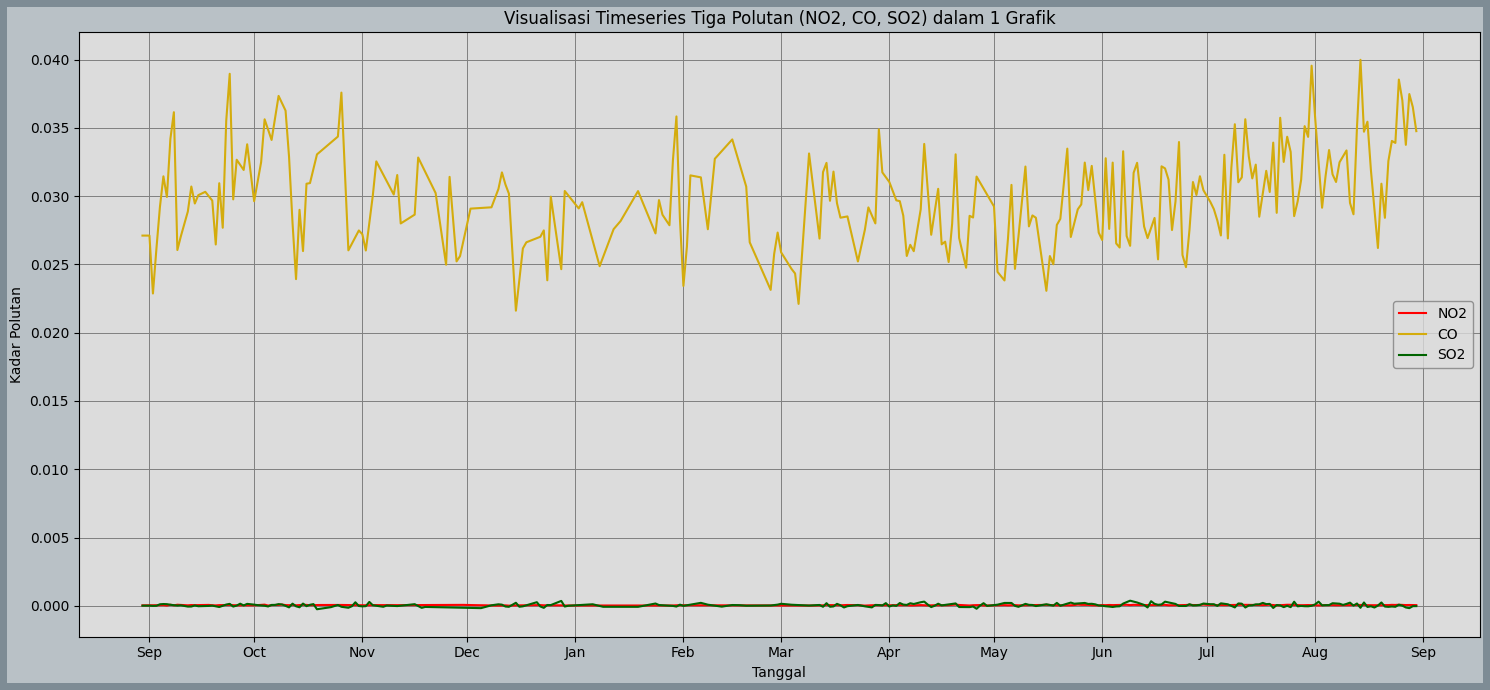

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load data bersih untuk ketiga polutan
try:
    df_no2 = pd.read_csv('NO2-Kerek-Clean.csv', parse_dates=['date'], index_col='date')
    df_co = pd.read_csv('CO-Kerek-Clean.csv', parse_dates=['date'], index_col='date')
    df_so2 = pd.read_csv('SO2-Kerek-Clean.csv', parse_dates=['date'], index_col='date')
    
    # Styling
    plt.rcParams['axes.facecolor'] = '#dcdcdc'
    plt.rcParams['figure.facecolor'] = '#b9c1c6'
    
    fig, ax = plt.subplots(figsize=(15, 7))
    
    # Plot NO2 (Merah)
    ax.plot(df_no2.index, df_no2['NO2'], color='red', linewidth=1.5, label='NO2')
    
    # Plot CO (Emas/Kuning)
    ax.plot(df_co.index, df_co['CO'], color='#d4ac0d', linewidth=1.5, label='CO')
    
    # Plot SO2 (Hijau Tua)
    ax.plot(df_so2.index, df_so2['SO2'], color='darkgreen', linewidth=1.5, label='SO2')
    
    ax.set_title('Visualisasi Timeseries Tiga Polutan (NO2, CO, SO2) dalam 1 Grafik')
    ax.set_xlabel('Tanggal')
    ax.set_ylabel('Kadar Polutan')
    
    # Konfigurasi sumbu X
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    
    # Grid gelap
    ax.grid(True, color='gray', linestyle='-', linewidth=0.7)
    
    # Legend kotak
    ax.legend(loc='center right', fancybox=True, facecolor='#dcdcdc', edgecolor='gray')
    
    # Border tebal figure
    fig.patch.set_edgecolor('#7e8c95')
    fig.patch.set_linewidth(10)
    
    plt.tight_layout()
    plt.show()
except FileNotFoundError as e:
    print('File tidak ditemukan:', e)


### 5. Install Library TSFEL Untuk Ekstraksi Fitur

In [11]:
pip install tsfel

  Using cached tsfel-0.2.0-py3-none-any.whl.metadata (9.4 kB)
  Using cached pywavelets-1.10.0-cp313-cp313-win_amd64.whl.metadata (7.6 kB)
  Using cached statsmodels-0.15.0-cp313-cp313-win_amd64.whl.metadata (9.6 kB)
  Using cached patsy-1.0.3-py2.py3-none-any.whl.metadata (3.7 kB)
  Using cached formulaic-1.2.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached interface_meta-2.0.1-py3-none-any.whl.metadata (6.4 kB)
Using cached tsfel-0.2.0-py3-none-any.whl (63 kB)
Using cached pywavelets-1.10.0-cp313-cp313-win_amd64.whl (4.3 MB)
Using cached statsmodels-0.15.0-cp313-cp313-win_amd64.whl (11.3 MB)
Using cached formulaic-1.2.2-py3-none-any.whl (118 kB)
Using cached interface_meta-2.0.1-py3-none-any.whl (15 kB)
Using cached patsy-1.0.3-py2.py3-none-any.whl (233 kB)

   ----- ---------------------------------- 1/7 [PyWavelets]
   ----------- ---------------------------- 2/7 [patsy]
   ----------------- ---------------------- 3/7 [interface-meta]
   ---------------------- ----------------- 

In [12]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [13]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


### 6. Penjelasan Setiap Fitur Serta Contoh Perhitungan Manual

Wavelet Entropy adalah fitur ekstraksi deret waktu yang mengukur tingkat kerumitan, ketidakteraturan (disorder), atau penyebaran energi dari suatu sinyal (dalam hal ini, data polutan seperti $NO_2$) pada berbagai skala frekuensi/waktu yang berbeda.

- Nilai Entropi Rendah : Sinyal Teratur/Stabil: Energi sinyal hanya terkonsentrasi pada sedikit skala saja

- Nilai Entropi Tinggi : Sinyal Kompleks/Fluktuatif/Acak: Energi sinyal tersebar merata ke banyak skala

Rumus Matematis TSFEL
Di dalam pustaka TSFEL, perhitungan `wavelet_entropy` menggunakan wavelet **Mexican Hat** (`mexh`) dengan rentang skala (*width*) dari $a = 1$ sampai $10$ (`max_width=10`). 

Langkah-langkah formulanya adalah sebagai berikut:

1. **Transformasi Wavelet & Energi per Skala ($E_a$):**
   Sinyal ditransformasikan menggunakan wavelet pada skala $a$ ($a = 1, 2, \dots, 10$). Energi pada setiap skala dihitung dari kuadrat koefisien wavelet-nya:
   $$E_a = \sum (\text{koefisien wavelet pada skala } a)^2$$

2. **Total Energi ($E_{\text{total}}$):**
   Menjumlahkan seluruh energi dari skala 1 sampai 10:
   $$E_{\text{total}} = \sum_{a=1}^{10} E_a$$

3. **Probabilitas Relatif ($p_a$):**
   Menghitung proporsi energi pada tiap skala terhadap total energi:
   $$p_a = \frac{E_a}{E_{\text{total}}}$$

4. **Shannon Entropy ($H_{we}$):**
   Menghitung tingkat ketidakteraturan menggunakan rumus entropi informasi berbasis logaritma basis 2:
   $$H_{we} = - \sum_{a=1}^{10} p_a \log_2(p_a)$$


Contoh Perhitungan Manual (Simulasi Sederhana)
Untuk memahami bagaimana angka akhir terbentuk, mari gunakan **3 skala pertama** ($a = 1, 2, 3$):

* **Langkah A: Energi per Skala ($E_a$) dari Data**
  * Skala 1 ($E_1$) = $2.0$
  * Skala 2 ($E_2$) = $4.0$
  * Skala 3 ($E_3$) = $2.0$

* **Langkah B: Total Energi ($E_{\text{total}}$)**
  $$E_{\text{total}} = 2.0 + 4.0 + 2.0 = 8.0$$

* **Langkah C: Probabilitas Relatif ($p_a$)**
  * $p_1 = \frac{2.0}{8.0} = 0.25$
  * $p_2 = \frac{4.0}{8.0} = 0.50$
  * $p_3 = \frac{2.0}{8.0} = 0.25$

* **Langkah D: Komponen Shannon Entropy ($-p_a \log_2 p_a$)**
  * Skala 1: $-(0.25 \times \log_2(0.25)) = -(0.25 \times -2.0) = 0.50$
  * Skala 2: $-(0.50 \times \log_2(0.50)) = -(0.50 \times -1.0) = 0.50$
  * Skala 3: $-(0.25 \times \log_2(0.25)) = -(0.25 \times -2.0) = 0.50$

* **Langkah E: Hasil Akhir Entropi**
  $$H_{we} = 0.50 + 0.50 + 0.50 = \mathbf{1.50}$$
  *(Catatan: Pada data riil 366 hari polutan Anda dengan skala 1 sampai 10, akumulasi perhitungan ini menghasilkan nilai akhir di kisaran **2.1**).*

### 7. Ekstraksi Menjadi 68 Fitur 

In [ ]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('NO2-Kerek-Clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'NO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}-Kerek-TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 0
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk NO2: 68


In [ ]:
df = pd.read_csv("NO2-Kerek-TSFEL.csv")
df.head(5)

,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,7.682415e-07,0.015739,7.0,2.104771e-09,195.079436,0.000088,0.000043,0.000043,0.000009,0.000016,...,0.14776,0.302308,3.122097e-10,0.002606,0.000003,0.000023,2.13666,0.000023,5.644993e-10,0.0


In [ ]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('CO-Kerek-Clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'CO'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}-Kerek-TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 0
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk CO: 68


In [ ]:
df = pd.read_csv("CO-Kerek-TSFEL.csv")
df.head(5)

,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,0.325552,10.822536,3.0,0.000892,185.172183,0.038546,0.029654,0.029505,0.021616,0.003179,...,0.130288,0.554103,0.000015,0.704421,0.001815,0.008006,2.144113,0.007772,0.000069,0.0


In [ ]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('SO2-Kerek-Clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'SO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}-Kerek-TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 0
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk SO2: 68


In [ ]:
df = pd.read_csv("SO2-Kerek-TSFEL.csv")
df.head(5)

,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,0.000005,0.028719,2.0,1.263833e-08,209.877355,0.000309,0.000033,0.000023,-0.000255,0.000107,...,0.148927,0.209776,1.899262e-08,0.027288,8.060801e-07,0.000153,2.160229,0.000153,2.464593e-08,93.0


### 8. Mengelompokkan Fitur Hasil Ekstraksi Berdasarkan Domain

In [ ]:
import pandas as pd

# ---------- 1. Muat hasil ekstraksi TSFEL ----------
df_features = pd.read_csv('NO2-Kerek-TSFEL.csv')

# ---------- 2. Mapping resmi fitur -> domain (sesuai features.json TSFEL) ----------
FEATURE_DOMAIN_MAP = {
    # Statistical (21)
    "abs_energy": "statistical", "average_power": "statistical", "calc_max": "statistical",
    "calc_mean": "statistical", "calc_median": "statistical", "calc_min": "statistical",
    "calc_std": "statistical", "calc_var": "statistical", "ecdf": "statistical",
    "ecdf_percentile": "statistical", "ecdf_percentile_count": "statistical",
    "ecdf_slope": "statistical", "entropy": "statistical", "hist_mode": "statistical",
    "interq_range": "statistical", "kurtosis": "statistical", "mean_abs_deviation": "statistical",
    "median_abs_deviation": "statistical", "pk_pk_distance": "statistical", "rms": "statistical",
    "skewness": "statistical",

    # Temporal (15)
    "auc": "temporal", "autocorr": "temporal", "calc_centroid": "temporal",
    "distance": "temporal", "lempel_ziv": "temporal", "mean_abs_diff": "temporal",
    "mean_diff": "temporal", "median_abs_diff": "temporal", "median_diff": "temporal",
    "negative_turning": "temporal", "neighbourhood_peaks": "temporal",
    "positive_turning": "temporal", "slope": "temporal", "sum_abs_diff": "temporal",
    "zero_cross": "temporal",

    # Spectral (26)
    "fundamental_frequency": "spectral", "human_range_energy": "spectral", "lpcc": "spectral",
    "max_frequency": "spectral", "max_power_spectrum": "spectral", "median_frequency": "spectral",
    "mfcc": "spectral", "power_bandwidth": "spectral", "spectral_centroid": "spectral",
    "spectral_decrease": "spectral", "spectral_distance": "spectral", "spectral_entropy": "spectral",
    "spectral_kurtosis": "spectral", "spectral_positive_turning": "spectral",
    "spectral_roll_off": "spectral", "spectral_roll_on": "spectral", "spectral_skewness": "spectral",
    "spectral_slope": "spectral", "spectral_spread": "spectral", "spectral_variation": "spectral",
    "spectrogram_mean_coeff": "spectral", "wavelet_abs_mean": "spectral", "wavelet_energy": "spectral",
    "wavelet_entropy": "spectral", "wavelet_std": "spectral", "wavelet_var": "spectral",

    # Fractal (6) - domain terpisah di TSFEL
    "dfa": "fractal", "higuchi_fractal_dimension": "fractal", "hurst_exponent": "fractal",
    "maximum_fractal_length": "fractal", "mse": "fractal", "petrosian_fractal_dimension": "fractal",
}

# ---------- 3. Kelompokkan kolom sesuai domain ----------
domain_columns = {"statistical": [], "temporal": [], "spectral": [], "fractal": [], "unknown": []}
for col in df_features.columns:
    domain = FEATURE_DOMAIN_MAP.get(col, "unknown")
    domain_columns[domain].append(col)

for domain, cols in domain_columns.items():
    print(f"{domain.upper()} ({len(cols)}): {cols}")

# ---------- 4. (Opsional) Pisah jadi DataFrame terpisah per domain ----------
df_statistical = df_features[domain_columns["statistical"]]
df_temporal = df_features[domain_columns["temporal"]]
df_spectral = df_features[domain_columns["spectral"]]
df_fractal = df_features[domain_columns["fractal"]]

# ---------- 5. (Opsional) Simpan masing-masing sebagai CSV terpisah ----------
df_statistical.to_csv('NO2_fitur_statistical.csv', index=False)
df_temporal.to_csv('NO2_fitur_temporal.csv', index=False)
df_spectral.to_csv('NO2_fitur_spectral.csv', index=False)
df_fractal.to_csv('NO2_fitur_fractal.csv', index=False)

STATISTICAL (21): ['abs_energy', 'average_power', 'calc_max', 'calc_mean', 'calc_median', 'calc_min', 'calc_std', 'calc_var', 'ecdf', 'ecdf_percentile', 'ecdf_percentile_count', 'ecdf_slope', 'entropy', 'hist_mode', 'interq_range', 'kurtosis', 'mean_abs_deviation', 'median_abs_deviation', 'pk_pk_distance', 'rms', 'skewness']
TEMPORAL (15): ['auc', 'autocorr', 'calc_centroid', 'distance', 'lempel_ziv', 'mean_abs_diff', 'mean_diff', 'median_abs_diff', 'median_diff', 'negative_turning', 'neighbourhood_peaks', 'positive_turning', 'slope', 'sum_abs_diff', 'zero_cross']
SPECTRAL (26): ['fundamental_frequency', 'human_range_energy', 'lpcc', 'max_frequency', 'max_power_spectrum', 'median_frequency', 'mfcc', 'power_bandwidth', 'spectral_centroid', 'spectral_decrease', 'spectral_distance', 'spectral_entropy', 'spectral_kurtosis', 'spectral_positive_turning', 'spectral_roll_off', 'spectral_roll_on', 'spectral_skewness', 'spectral_slope', 'spectral_spread', 'spectral_variation', 'spectrogram_mean_